Data successfully anonymized and saved as productivity_data_features.csv!

--- Summary Statistics ---


,Sleep_Hours,Phone_Screen_Time_Hours,Study_Hours,Classes_Attended,Mood_Score_1_to_10,Productivity_Score_1_to_10
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,6.207568,6.925405,3.324324,2.027027,5.351351,5.135135
std,2.202219,1.762215,3.232251,1.992855,2.030547,2.056996
min,0.500000,3.470000,0.000000,0.000000,1.000000,1.000000
25%,5.330000,5.680000,0.000000,0.000000,4.000000,4.000000
50%,6.170000,6.820000,3.000000,2.000000,5.000000,5.000000
75%,7.330000,8.250000,6.000000,3.000000,7.000000,6.000000
max,10.330000,12.250000,10.000000,7.000000,9.000000,9.000000


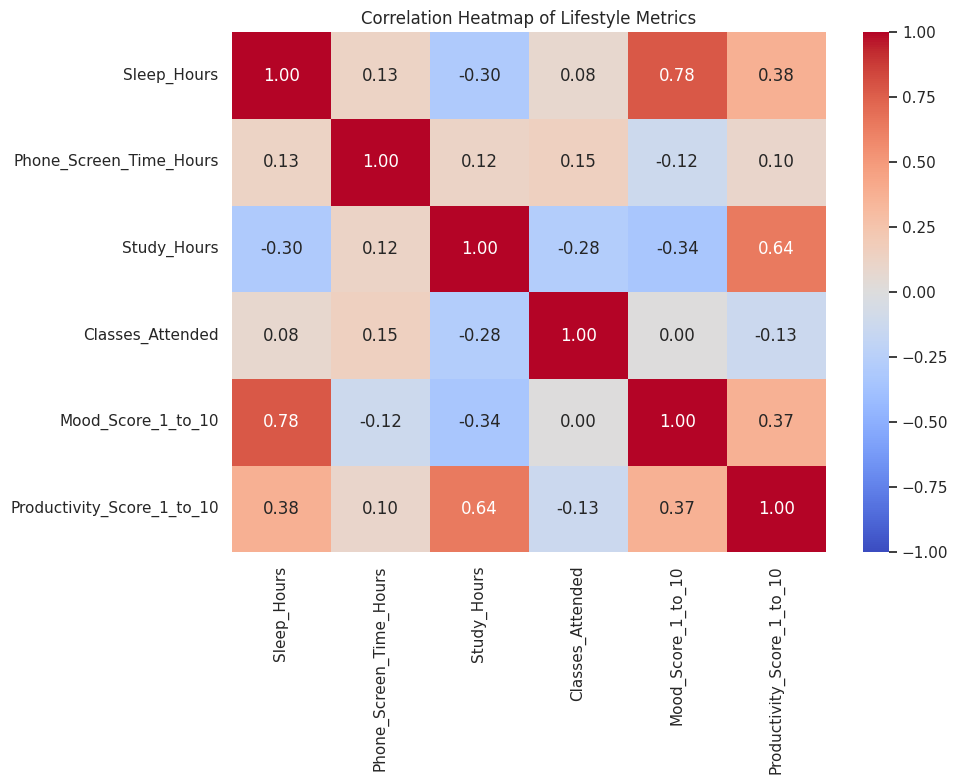

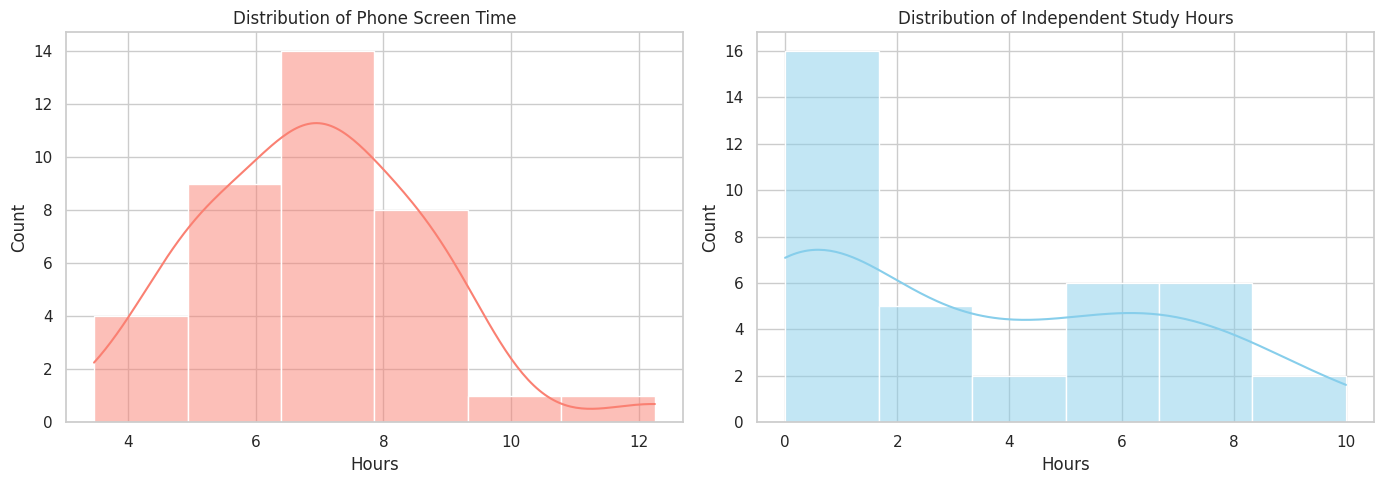

--- Hypothesis 1: Does longer sleep duration lead to higher productivity? ---
Pearson Correlation Coefficient: 0.376
P-value: 0.022
Conclusion: There is a statistically significant relationship between sleep and productivity.

-------------------------------------------------------------------

--- Hypothesis 2: Does increased phone usage negatively affect study time? ---
Pearson Correlation Coefficient: 0.121
P-value: 0.476
Conclusion: We fail to reject the null hypothesis. No statistically significant relationship was found.

-------------------------------------------------------------------

--- MACHINE LEARNING MODEL RESULTS ---

How do your habits affect productivity? (Feature Coefficients)
🔹 Sleep_Hours: Increases productivity by 0.56 points per hour.
🔻 Phone_Screen_Time_Hours: Decreases productivity by 0.14 points per hour.
🔹 Study_Hours: Increases productivity by 0.53 points per hour.

Model Accuracy Metrics:
R-squared: 0.68
Mean Squared Error: 1.21



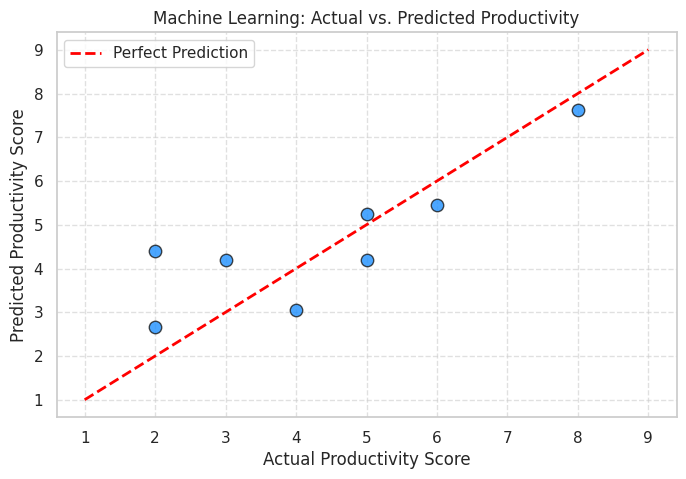

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#DATA PREPARATION
# Load dataset
df_raw = pd.read_csv('dsa210_collected_data.csv')

# Drop the date to anonymize
df_features = df_raw.drop(columns=['Date'])

# Save the safe dataset
df_features.to_csv('productivity_data_features.csv', index=False)
print("Data successfully anonymized and saved as productivity_data_features.csv!\n")

# Load anonymized dataset
df = pd.read_csv('productivity_data_features.csv')

print("--- Summary Statistics ---")
display(df.describe())

#EDA
sns.set_theme(style="whitegrid")

# Graph 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title("Correlation Heatmap of Lifestyle Metrics")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

# Graph 2: Distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Phone_Screen_Time_Hours'], bins=6, kde=True, ax=ax[0], color='salmon')
ax[0].set_title('Distribution of Phone Screen Time')
ax[0].set_xlabel('Hours')

sns.histplot(df['Study_Hours'], bins=6, kde=True, ax=ax[1], color='skyblue')
ax[1].set_title('Distribution of Independent Study Hours')
ax[1].set_xlabel('Hours')

plt.tight_layout()
plt.savefig("distributions.png")
plt.show()

#HYPOTHESIS TESTING
print("--- Hypothesis 1: Does longer sleep duration lead to higher productivity? ---")
sleep_corr, sleep_p_value = stats.pearsonr(df['Sleep_Hours'], df['Productivity_Score_1_to_10'])
print(f"Pearson Correlation Coefficient: {sleep_corr:.3f}")
print(f"P-value: {sleep_p_value:.3f}")

if sleep_p_value < 0.05:
    print("Conclusion: There is a statistically significant relationship between sleep and productivity.")
else:
    print("Conclusion: We fail to reject the null hypothesis. The relationship is not statistically significant.")

print("\n-------------------------------------------------------------------\n")

print("--- Hypothesis 2: Does increased phone usage negatively affect study time? ---")
phone_corr, phone_p_value = stats.pearsonr(df['Phone_Screen_Time_Hours'], df['Study_Hours'])
print(f"Pearson Correlation Coefficient: {phone_corr:.3f}")
print(f"P-value: {phone_p_value:.3f}")

if phone_p_value < 0.05:
    print("Conclusion: There is a statistically significant relationship between phone screen time and study hours.")
else:
    print("Conclusion: We fail to reject the null hypothesis. No statistically significant relationship was found.")

print("\n-------------------------------------------------------------------\n")


#MACHINE LEARNING
print("--- MACHINE LEARNING MODEL RESULTS ---\n")

# 1. Set up our Machine Learning features
X = df[['Sleep_Hours', 'Phone_Screen_Time_Hours', 'Study_Hours']]
y = df['Productivity_Score_1_to_10']

# 2. Split the data (80% for training the ML, 20% for testing it)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model!
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Print the Results
print("How do your habits affect productivity? (Feature Coefficients)")
for feature, coef in zip(X.columns, model.coef_):
    if coef > 0:
        print(f"🔹 {feature}: Increases productivity by {coef:.2f} points per hour.")
    else:
        print(f"🔻 {feature}: Decreases productivity by {abs(coef):.2f} points per hour.")

print("\nModel Accuracy Metrics:")
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}\n")

# 6. Visualize the ML Predictions
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='dodgerblue', alpha=0.8, edgecolors='k', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Machine Learning: Actual vs. Predicted Productivity')
plt.xlabel('Actual Productivity Score')
plt.ylabel('Predicted Productivity Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Save the ML plot
plt.savefig('ml_prediction_scatter.png', bbox_inches='tight')
plt.show()